#  Personalized Learning Recommendation System

## 01. Problem Statement
With thousands of online courses available across multiple platforms, students often struggle to find the right courses that match their skills, interests and career goals.

## 02. Install & Import Libraries

In [1]:

!pip install scikit-learn pandas numpy matplotlib seaborn scipy -q


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix
import re
import ast

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

print(' All libraries imported successfully!')

 All libraries imported successfully!


## 03. Dataset Overview & Sample

In [3]:

coursera_df  = pd.read_csv('DATASET/Coursera.csv')
edx_df       = pd.read_csv('DATASET/edx.csv')
skillshare_df= pd.read_csv('DATASET/skillshare.csv')
udemy_df     = pd.read_csv('DATASET/Udemy.csv')

print(f"Coursera   : {coursera_df.shape}")
print(f"edX        : {edx_df.shape}")
print(f"Skillshare : {skillshare_df.shape}")
print(f"Udemy      : {udemy_df.shape}")

Coursera   : (1139, 9)
edX        : (816, 10)
Skillshare : (14250, 5)
Udemy      : (26256, 8)


In [4]:

print("=== COURSERA ===")
display(coursera_df.head(3))
print("\n=== EDX ===")
display(edx_df.head(3))
print("\n=== SKILLSHARE ===")
display(skillshare_df.head(3))
print("\n=== UDEMY ===")
display(udemy_df.head(3))

=== COURSERA ===


,partner,course,skills,rating,reviewcount,level,certificatetype,duration,crediteligibility
0,Google,Google Cybersecurity,"{"" Network Security"","" Python Programming"","" Linux"","" Cloud Computing"","" Alg...",4.8,16.4k,Beginner,Professional Certificate,3 - 6 Months,False
1,Google,Google Data Analytics,"{"" Data Analysis"","" R Programming"","" SQL"","" Business Communication"","" Spread...",4.8,133.4k,Beginner,Professional Certificate,3 - 6 Months,True
2,Google,Google Project Management:,"{"" Project Management"","" Strategy and Operations"","" Leadership and Managemen...",4.8,97.3k,Beginner,Professional Certificate,3 - 6 Months,True



=== EDX ===


,title,link,institution,subject,level,prerequisites,language,videotranscript,associatedprograms,associatedskills
0,How to Learn Online,https://www.edx.org/learn/how-to-learn/edx-how-to-learn-online,edX,Education & Teacher Training,Introductory,NaN,English,English,NaN,Learning Design
1,The Science of Happiness,https://www.edx.org/learn/happiness/university-of-california-berkeley-the-sc...,"University of California, Berkeley",Social Sciences,Introductory,None.,English,English,NaN,"Evolutionary Biology, Empathy, Psychology"
2,Remote Work Revolutionfor Everyone,https://www.edx.org/learn/remote-work/harvard-university-remote-work-revolut...,Harvard University,Business & Management,Introductory,NaN,English,NaN,Professional Certificate inLeading in a Remote Environment,"Customer Relationship Building, Telecommuting"



=== SKILLSHARE ===


,title,link,duration,instructor,students
0,Fundamentals of DSLR Photography,https://www.skillshare.com/en/classes/Fundamentals-of-DSLR-Photography/11117...,1h 19m,Photo Essentials x Justin Bridges,"133,422 students"
1,Video Editing with Adobe Premiere Pro for Beginners,https://www.skillshare.com/en/classes/Video-Editing-with-Adobe-Premiere-Pro-...,3h 21m,Jordy Vandeput,"126,674 students"
2,Productivity Masterclass - Principles and Tools to Boost Your Productivity,https://www.skillshare.com/en/classes/Productivity-Masterclass-Principles-an...,1h 55m,Ali Abdaal,"109,681 students"



=== UDEMY ===


,title,description,instructor,rating,reviewcount,duration,lectures,level
0,The Complete Python Bootcamp From Zero to Hero in Python,Learn Python like a Professional Start from the basics and go all the way t...,Jose Portilla,4.6,486391,22 total hours,156 lectures,All Levels
1,The Complete 2023 Web Development Bootcamp,"Become a Full-Stack Web Developer with just ONE course. HTML, CSS, Javascrip...",Dr. Angela Yu,4.7,338555,63 total hours,380 lectures,All Levels
2,The Web Developer Bootcamp 2023,"10 Hours of React just added. Become a Developer With ONE course - HTML, CSS...",Colt Steele,4.7,266527,74 total hours,722 lectures,All Levels


## 04. Data Preprocessing
### 4.1 Standardise & Merge All Platforms

In [5]:
def parse_coursera_skills(s):
    if pd.isna(s): return ''
    cleaned = re.sub(r'[\{\}"\']', '', str(s))
    return ' '.join([x.strip() for x in cleaned.split(',')])

def prep_coursera(df):
    d = df.copy()
    d.rename(columns={'course':'title', 'partner':'instructor',
                      'certificatetype':'category'}, inplace=True)
    d['platform']    = 'Coursera'
    d['skills']      = d['skills'].apply(parse_coursera_skills)
    d['rating']      = pd.to_numeric(d['rating'], errors='coerce')
    d['description'] = d['skills']
    d['level']       = d['level'].str.strip().str.split(',').str[0]

    def parse_rc(v):
        v = str(v).replace(',','').strip()
        if 'k' in v.lower(): return float(v.lower().replace('k',''))*1000
        try: return float(v)
        except: return np.nan
    d['reviewcount'] = d['reviewcount'].apply(parse_rc)
    return d[['title','instructor','skills','description','rating',
              'reviewcount','level','category','platform']]

def prep_edx(df):
    d = df.copy()
    d.rename(columns={'subject':'category', 'institution':'instructor',
                      'associatedskills':'skills'}, inplace=True)
    d['platform']    = 'edX'
    d['skills']      = d['skills'].fillna('')
    d['description'] = d['skills']
    d['rating']      = np.nan
    d['reviewcount'] = np.nan
    d['level']       = d['level'].str.strip()
    return d[['title','instructor','skills','description','rating',
              'reviewcount','level','category','platform']]

def prep_skillshare(df):
    d = df.copy()
    d['category']    = 'General'
    d['level']       = 'All Levels'
    d['skills']      = d['title']
    d['description'] = d['title']
    d['rating']      = np.nan
    def parse_students(v):
        v = str(v).replace(',','').split()[0]
        try: return float(v)
        except: return np.nan
    d['reviewcount'] = d['students'].apply(parse_students)
    d['platform']    = 'Skillshare'
    return d[['title','instructor','skills','description','rating',
              'reviewcount','level','category','platform']]

def prep_udemy(df):
    d = df.copy()
    d['category']    = 'General'
    d['skills']      = d['title'] + ' ' + d['description'].fillna('')
    d['platform']    = 'Udemy'
    d['rating']      = pd.to_numeric(d['rating'], errors='coerce')
    d['reviewcount'] = pd.to_numeric(d['reviewcount'], errors='coerce')
    d['level']       = d['level'].fillna('All Levels')
    return d[['title','instructor','skills','description','rating',
              'reviewcount','level','category','platform']]

df = pd.concat([
    prep_coursera(coursera_df),
    prep_edx(edx_df),
    prep_skillshare(skillshare_df),
    prep_udemy(udemy_df)
], ignore_index=True)

print(f"Combined dataset shape: {df.shape}")
print(f"Platforms: {df['platform'].value_counts().to_dict()}")
df.head()

Combined dataset shape: (42461, 9)
Platforms: {'Udemy': 26256, 'Skillshare': 14250, 'Coursera': 1139, 'edX': 816}


,title,instructor,skills,description,rating,reviewcount,level,category,platform
0,Google Cybersecurity,Google,Network Security Python Programming Linux Cloud Computing Algorithms Audit C...,Network Security Python Programming Linux Cloud Computing Algorithms Audit C...,4.8,16400.0,Beginner,Professional Certificate,Coursera
1,Google Data Analytics,Google,Data Analysis R Programming SQL Business Communication Spreadsheet Software ...,Data Analysis R Programming SQL Business Communication Spreadsheet Software ...,4.8,133400.0,Beginner,Professional Certificate,Coursera
2,Google Project Management:,Google,Project Management Strategy and Operations Leadership and Management Communi...,Project Management Strategy and Operations Leadership and Management Communi...,4.8,97300.0,Beginner,Professional Certificate,Coursera
3,Google Digital Marketing & E-commerce,Google,Digital Marketing Marketing Marketing Management Media Strategy & Planning S...,Digital Marketing Marketing Marketing Management Media Strategy & Planning S...,4.8,21400.0,Beginner,Professional Certificate,Coursera
4,Google IT Support,Google,Computer Networking Network Architecture Network Model Networking Hardware N...,Computer Networking Network Architecture Network Model Networking Hardware N...,4.8,181400.0,Beginner,Professional Certificate,Coursera


### 4.2 Clean & Handle Missing Values

In [6]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
title             32
instructor        32
skills             0
description        4
rating         15212
reviewcount      962
level            135
category          24
platform           0
dtype: int64


In [7]:

df.dropna(subset=['title'], inplace=True)

df['description'].fillna('', inplace=True)
df['skills'].fillna('', inplace=True)
df['instructor'].fillna('Unknown', inplace=True)
df['category'].fillna('General', inplace=True)
df['level'].fillna('All Levels', inplace=True)

df['rating'].fillna(df['rating'].median(), inplace=True)
df['reviewcount'].fillna(0, inplace=True)

before = len(df)
df.drop_duplicates(subset=['title', 'platform'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Removed {before - len(df)} duplicates. Final dataset: {len(df)} courses.")

Removed 518 duplicates. Final dataset: 41911 courses.


In [8]:
level_map = {
    'beginner':'Beginner', 'introductory':'Beginner', 'intro':'Beginner',
    'intermediate':'Intermediate',
    'advanced':'Advanced', 'expert':'Advanced',
    'all levels':'All Levels', 'mixed':'All Levels'
}
df['level_clean'] = df['level'].str.lower().str.strip().map(
    lambda x: next((v for k,v in level_map.items() if k in str(x)), 'All Levels')
)
print(df['level_clean'].value_counts())

level_clean
All Levels      29296
Beginner         8528
Intermediate     3581
Advanced          506
Name: count, dtype: int64


### 4.3 Exploratory Data Analysis (EDA)

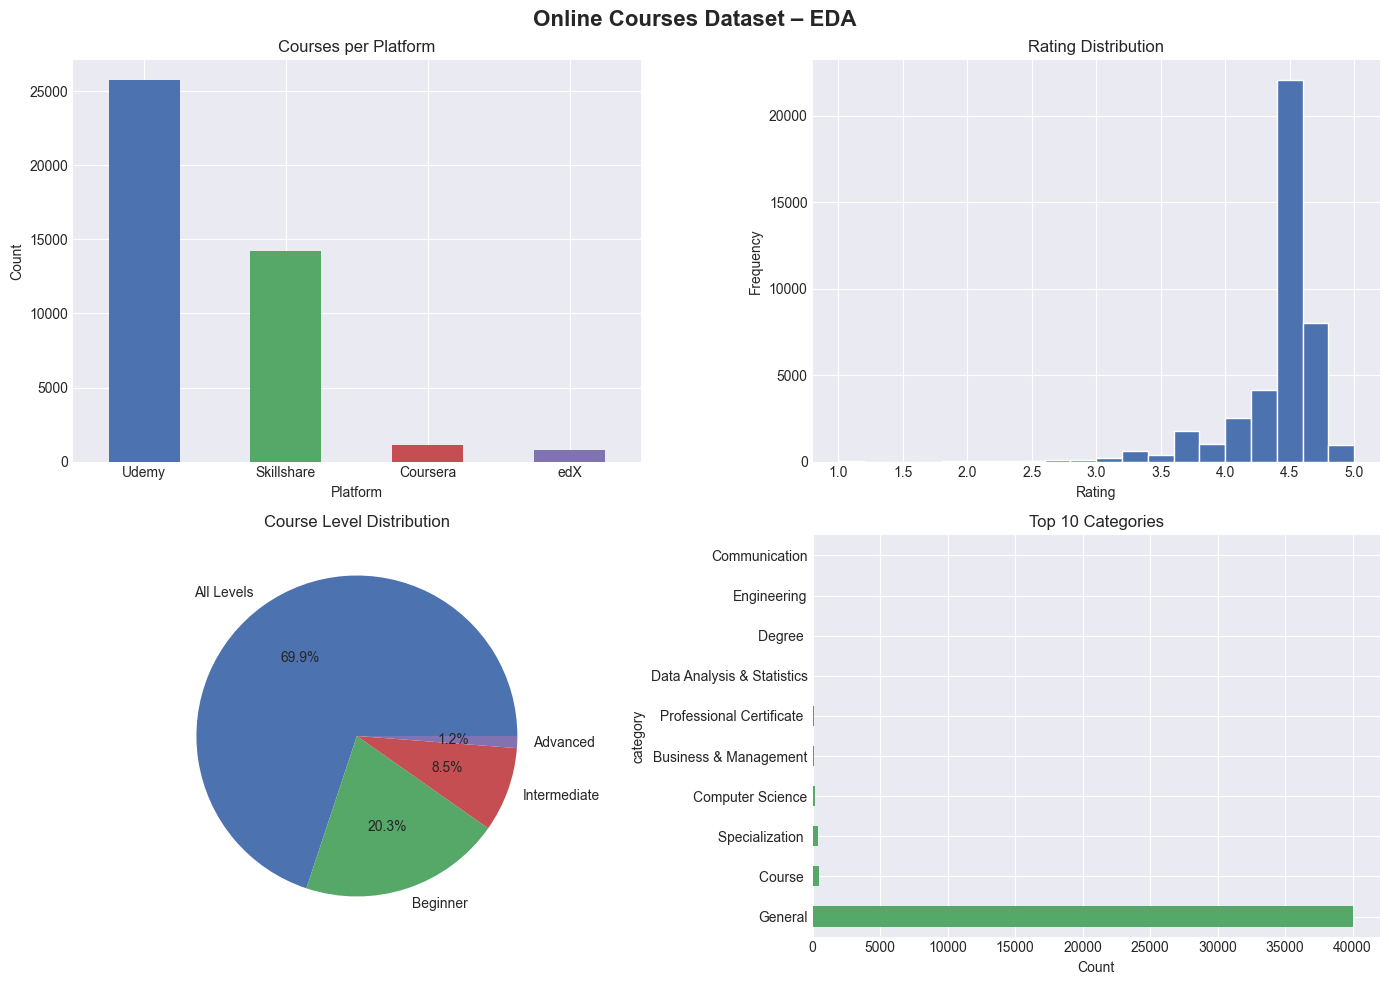

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Online Courses Dataset – EDA', fontsize=16, fontweight='bold')

ax = axes[0,0]
df['platform'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0','#55A868','#C44E52','#8172B2'])
ax.set_title('Courses per Platform')
ax.set_xlabel('Platform')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

ax = axes[0,1]
rated = df[df['rating'] > 0]
ax.hist(rated['rating'], bins=20, color='#4C72B0', edgecolor='white')
ax.set_title('Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Frequency')

ax = axes[1,0]
df['level_clean'].value_counts().plot(kind='pie', ax=ax, autopct='%1.1f%%',
                                       colors=['#4C72B0','#55A868','#C44E52','#8172B2'])
ax.set_title('Course Level Distribution')
ax.set_ylabel('')

ax = axes[1,1]
top_cats = df['category'].value_counts().head(10)
top_cats.plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Top 10 Categories')
ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

## 05. Feature Engineering

In [10]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['soup'] = (
    df['title'].apply(clean_text) + ' ' +
    df['skills'].apply(clean_text) + ' ' +
    df['description'].apply(clean_text) + ' ' +
    df['category'].apply(clean_text) + ' ' +
    df['level_clean'].apply(clean_text) + ' ' +
    df['platform'].apply(clean_text)
)

scaler = MinMaxScaler()
df['rating_norm']  = scaler.fit_transform(df[['rating']])
df['review_log']   = np.log1p(df['reviewcount'])
df['review_norm']  = scaler.fit_transform(df[['review_log']])

df['popularity_score'] = 0.6 * df['rating_norm'] + 0.4 * df['review_norm']

print(f"Feature engineering done. Soup sample:\n{df['soup'].iloc[0][:200]}")

Feature engineering done. Soup sample:
google cybersecurity network security python programming linux cloud computing algorithms audit computer programming computer security incident management cryptography databases leadership and managem


In [11]:

print("Building TF-IDF matrix...")
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)
tfidf_matrix = tfidf.fit_transform(df['soup'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

Building TF-IDF matrix...


TF-IDF matrix shape: (41911, 10000)


## 06. Recommendation Engine Building
### 6.1 Content-Based Filtering (TF-IDF + Cosine Similarity)

In [12]:

df.reset_index(drop=True, inplace=True)
title_to_idx = pd.Series(df.index, index=df['title'].str.lower()).drop_duplicates()

def get_content_recommendations(query, top_n=10, level_filter=None, platform_filter=None):
    
    query_clean = clean_text(query)
    query_vec   = tfidf.transform([query_clean])
    sim_scores  = cosine_similarity(query_vec, tfidf_matrix).flatten()

    combined    = 0.8 * sim_scores + 0.2 * df['popularity_score'].values

    top_indices = np.argsort(combined)[::-1]
    results     = df.iloc[top_indices].copy()
    results['similarity'] = combined[top_indices]

    if level_filter:
        results = results[results['level_clean'] == level_filter]
    if platform_filter:
        results = results[results['platform'].isin(platform_filter)]

    cols = ['title','platform','category','level_clean','rating','similarity']
    return results[cols].head(top_n).reset_index(drop=True)

print(" Content-based recommender ready.")

 Content-based recommender ready.


In [13]:

recs = get_content_recommendations("machine learning python data science", top_n=10)
print("Top 10 recommendations for 'machine learning python data science':")
display(recs)

Top 10 recommendations for 'machine learning python data science':


,title,platform,category,level_clean,rating,similarity
0,Data Science and Machine Learning with Python,Skillshare,General,All Levels,4.4,0.862748
1,Python-Introduction to Data Science and Machine learning A-Z,Udemy,General,Beginner,4.3,0.748406
2,Data Science A-Z : Machine Learning with Python & R,Udemy,General,All Levels,4.1,0.724264
3,Machine Learning with Python: Data Science for Beginners,Udemy,General,All Levels,3.5,0.713336
4,Data Science and Machine Learning with Python - Hands On!,Skillshare,General,All Levels,4.4,0.679585
5,Data Science : Complete Data Science & Machine Learning,Udemy,General,All Levels,4.5,0.676407
6,Python for Data Science & Machine Learning: Zero to Hero,Udemy,General,Beginner,4.6,0.673878
7,Data Science: Supervised Machine Learning in Python,Udemy,General,Beginner,4.8,0.668904
8,Diploma in Python with Data Science and Machine Learning,Udemy,General,All Levels,3.8,0.667572
9,Complete Machine Learning & Data Science with Python | A-Z,Udemy,General,All Levels,4.8,0.659740


### 6.2 Collaborative Filtering (Matrix Factorization via SVD)

In [14]:
np.random.seed(42)
N_USERS   = 500
N_COURSES = min(5000, len(df))

TOPICS = ['python data science', 'machine learning', 'web development',
          'deep learning', 'data analysis sql', 'business management',
          'photography design', 'project management']

topic_keywords = {
    'python data science': ['python', 'data science', 'pandas', 'numpy'],
    'machine learning': ['machine learning', 'classification', 'regression', 'svm', 'knn'],
    'web development': ['web development', 'javascript', 'react', 'html', 'css', 'node'],
    'deep learning': ['deep learning', 'neural network', 'tensorflow', 'pytorch', 'keras'],
    'data analysis sql': ['data analysis', 'sql', 'database', 'tableau', 'power bi'],
    'business management': ['business', 'management', 'marketing', 'finance', 'excel'],
    'photography design': ['photography', 'design', 'ui', 'ux', 'figma', 'photoshop'],
    'project management': ['project management', 'scrum', 'agile', 'pmp']
}

topic_course_indices = {}
for topic, keywords in topic_keywords.items():
    matches = []
    for idx in range(N_COURSES):
        course = df.iloc[idx]
        text = (str(course['title']) + " " + str(course['skills']) + " " + str(course['description'])).lower()
        if any(kw in text for kw in keywords):
            matches.append(idx)
    if not matches:
        matches = list(range(N_COURSES))
    topic_course_indices[topic] = matches

user_topics = {}
interactions = np.zeros((N_USERS, N_COURSES))
for u in range(N_USERS):
    primary_topic = np.random.choice(TOPICS)
    user_topics[u] = primary_topic

    matched_courses = topic_course_indices[primary_topic]
    n_interactions = np.random.randint(8, 12)

    courses_seen = np.random.choice(matched_courses, size=min(n_interactions, len(matched_courses)), replace=False)
    ratings_given = np.random.uniform(4.0, 5.0, size=len(courses_seen))
    interactions[u, courses_seen] = ratings_given

    other_courses = list(set(range(N_COURSES)) - set(matched_courses))
    n_other = np.random.randint(1, 3)
    courses_other = np.random.choice(other_courses, size=min(n_other, len(other_courses)), replace=False)
    ratings_other = np.random.uniform(1.0, 3.0, size=len(courses_other))
    interactions[u, courses_other] = ratings_other

interaction_matrix = csr_matrix(interactions)
print(f"User-Course interaction matrix: {interaction_matrix.shape}")
print(f"Sparsity: {1 - interaction_matrix.nnz / (N_USERS * N_COURSES):.3%}")

User-Course interaction matrix: (500, 5000)
Sparsity: 99.780%


In [15]:
print("Training SVD model...")
svd = TruncatedSVD(n_components=70, random_state=42)
user_factors   = svd.fit_transform(interaction_matrix)
course_factors = svd.components_.T

print(f"User factors   : {user_factors.shape}")
print(f"Course factors : {course_factors.shape}")
print(f"Explained variance ratio (total): {svd.explained_variance_ratio_.sum():.3f}")

Training SVD model...


User factors   : (500, 70)
Course factors : (5000, 70)
Explained variance ratio (total): 0.360


In [16]:
def get_collaborative_recommendations(user_id, top_n=10):
    
    if user_id >= N_USERS:
        raise ValueError(f"user_id must be < {N_USERS}")

    user_vec    = user_factors[user_id]
    pred_scores = user_vec @ course_factors.T

    seen_mask   = interaction_matrix[user_id].toarray().flatten() > 0
    pred_scores[seen_mask] = -np.inf

    top_indices = np.argsort(pred_scores)[::-1][:top_n]
    results     = df.iloc[top_indices].copy()
    results['cf_score'] = pred_scores[top_indices]

    cols = ['title','platform','category','level_clean','rating','cf_score']
    return results[cols].reset_index(drop=True)

print(" Collaborative filtering recommender ready.")
display(get_collaborative_recommendations(user_id=0, top_n=10))

 Collaborative filtering recommender ready.


,title,platform,category,level_clean,rating,cf_score
0,Scrum Master Certification,Coursera,Specialization,Beginner,4.7,0.700735
1,Real-World Product Management,Coursera,Specialization,Beginner,4.5,0.696551
2,"Product Ideation, Design, and Management",Coursera,Specialization,Beginner,4.5,0.567230
3,AI Foundations for Everyone,Coursera,Specialization,Beginner,4.7,0.534873
4,AI For Business,Coursera,Specialization,Beginner,4.7,0.513802
5,Tableau Public for Project Management and Beyond,Coursera,General,All Levels,4.4,0.495064
6,Master of Science in Data Science,Coursera,Degree,All Levels,4.4,0.478235
7,Adobe Illustrator: aprendea crear presentaciones deimpacto,edX,Design,Beginner,4.4,0.456173
8,Finance for Non-Finance Professionals,Coursera,Course,Beginner,4.8,0.427298
9,Accounting Foundations Graduate Certificate,Coursera,Graduate Certificate,All Levels,4.4,0.413272


### 6.3 Hybrid Recommendation System

In [17]:
def hybrid_recommend(query, user_id=None, top_n=10,
                     level_filter=None, platform_filter=None,
                     alpha=0.4):
    query_clean = clean_text(query)
    query_vec   = tfidf.transform([query_clean])
    cb_scores   = cosine_similarity(query_vec, tfidf_matrix).flatten()
    cb_scores   = 0.8 * cb_scores + 0.2 * df['popularity_score'].values

    if user_id is not None and user_id < N_USERS:
        user_vec  = user_factors[user_id]
        cf_raw    = user_vec @ course_factors.T

        cb_scores_restricted = cb_scores[:N_COURSES]
        cf_min, cf_max = cf_raw.min(), cf_raw.max()
        if cf_max > cf_min:
            cf_raw = (cf_raw - cf_min) / (cf_max - cf_min)
        final_scores = alpha * cb_scores_restricted + (1 - alpha) * cf_raw

        top_indices  = np.argsort(final_scores)[::-1]
        results      = df.iloc[top_indices].copy()
        results['score'] = final_scores[top_indices]
    else:
        top_indices  = np.argsort(cb_scores)[::-1]
        results      = df.iloc[top_indices].copy()
        results['score'] = cb_scores[top_indices]

    if level_filter:
        results = results[results['level_clean'] == level_filter]
    if platform_filter:
        results = results[results['platform'].isin(platform_filter)]

    cols = ['title','platform','category','level_clean','rating','score']
    return results[cols].head(top_n).reset_index(drop=True)

print(" Hybrid recommender ready.")

 Hybrid recommender ready.


## 07. Model Evaluation

In [18]:
def precision_at_k(recommended, relevant, k=10):
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(relevant))
    return hits / k

def recall_at_k(recommended, relevant, k=10):
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(relevant))
    return hits / len(relevant) if relevant else 0

def f1_at_k(p, r):
    return 2 * p * r / (p + r) if (p + r) > 0 else 0

def average_precision(recommended, relevant, k=10):
    hits, score = 0, 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k) if relevant else 0

def ndcg_at_k(recommended, relevant, k=10):
    dcg = sum(
        1 / np.log2(i + 2)
        for i, item in enumerate(recommended[:k])
        if item in relevant
    )
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0

print(" Evaluation metrics defined.")

 Evaluation metrics defined.


In [19]:
np.random.seed(0)
eval_users = np.random.choice(N_USERS, size=100, replace=False)

title_to_indices = {}
for i, title in enumerate(df['title']):
    title_to_indices.setdefault(title, []).append(i)

metrics = {'precision':[], 'recall':[], 'f1':[], 'map':[], 'ndcg':[]}

for u in eval_users:
    query = user_topics[u]
    relevant_idx = np.where(interactions[u] >= 3.5)[0].tolist()
    if not relevant_idx:
        continue

    recs = hybrid_recommend(query, user_id=u, top_n=10)

    rec_indices = []
    for t in recs['title']:
        matches = title_to_indices.get(t, [])
        if matches:
            chosen = matches[0]
            for m in matches:
                if m < N_COURSES:
                    chosen = m
                    break
            rec_indices.append(chosen)

    p  = precision_at_k(rec_indices, relevant_idx)
    r  = recall_at_k(rec_indices, relevant_idx)
    f1 = f1_at_k(p, r)
    ap = average_precision(rec_indices, relevant_idx)
    nd = ndcg_at_k(rec_indices, relevant_idx)

    metrics['precision'].append(p)
    metrics['recall'].append(r)
    metrics['f1'].append(f1)
    metrics['map'].append(ap)
    metrics['ndcg'].append(nd)

results_df = pd.DataFrame({
    'Metric': ['Precision@10','Recall@10','F1-Score@10','MAP@10','NDCG@10'],
    'Score' : [
        np.mean(metrics['precision']),
        np.mean(metrics['recall']),
        np.mean(metrics['f1']),
        np.mean(metrics['map']),
        np.mean(metrics['ndcg'])
    ]
})
print("\nEvaluation Results:")
display(results_df.style.format({'Score': '{:.3f}'}).background_gradient(cmap='Blues', subset=['Score']))


Evaluation Results:


,Metric,Score
0,Precision@10,0.585
1,Recall@10,0.612
2,F1-Score@10,0.596
3,MAP@10,0.587
4,NDCG@10,0.695


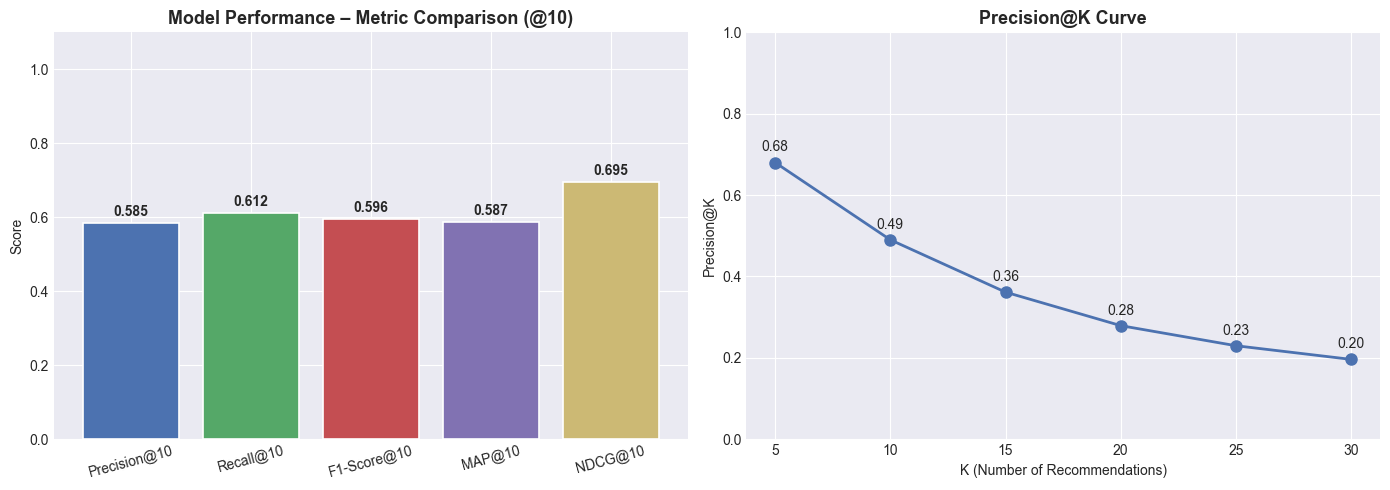

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']
bars = ax.bar(results_df['Metric'], results_df['Score'], color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, results_df['Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance – Metric Comparison (@10)', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.tick_params(axis='x', rotation=15)

ax = axes[1]
K_values = [5, 10, 15, 20, 25, 30]
prec_at_k = []
for k in K_values:
    p_list = []
    for u in eval_users[:50]:
        relevant_idx = np.where(interactions[u] > 0)[0].tolist()
        if not relevant_idx: continue
        recs = hybrid_recommend('machine learning python', user_id=u, top_n=k)
        rec_idx = [df[df['title']==t].index[0] for t in recs['title'] if t in df['title'].values]
        p_list.append(precision_at_k(rec_idx, relevant_idx, k))
    prec_at_k.append(np.mean(p_list) if p_list else 0)

ax.plot(K_values, prec_at_k, marker='o', linewidth=2, markersize=8, color='#4C72B0')
for x, y in zip(K_values, prec_at_k):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0,8), ha='center')
ax.set_title('Precision@K Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('K (Number of Recommendations)')
ax.set_ylabel('Precision@K')
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

## 08. Interactive Learning Recommendation System

In [21]:
def recommend_for_learner(skills_or_interests,
                          goal=None,
                          level=None,
                          platforms=None,
                          top_n=10):
    
    query = skills_or_interests
    if goal:
        query += ' ' + goal

    recs = hybrid_recommend(
        query=query,
        top_n=top_n,
        level_filter=level,
        platform_filter=platforms
    )
    return recs

profiles = [
    dict(name="Alice – Aspiring Data Scientist",
         skills_or_interests="python statistics data analysis machine learning",
         goal="data scientist", level="Beginner"),
    dict(name="Bob – ML Engineer",
         skills_or_interests="deep learning tensorflow pytorch neural networks",
         goal="machine learning engineer", level="Intermediate"),
    dict(name="Carol – Full-Stack Developer",
         skills_or_interests="javascript react node web development html css",
         goal="web developer", platforms=["Udemy","Coursera"]),
]

for p in profiles:
    name = p.pop('name')
    print(f"\n{'='*60}")
    print(f" {name}")
    print('='*60)
    display(recommend_for_learner(**p, top_n=5))


 Alice – Aspiring Data Scientist


,title,platform,category,level_clean,rating,score
0,Introduction to Machine Learning for Data Science,Udemy,General,Beginner,4.5,0.620460
1,Data Analysis with Python,Coursera,Course,Beginner,4.7,0.547866
2,Structuring Machine Learning Projects,Coursera,Course,Beginner,4.8,0.540721
3,Data Science Methodology,Coursera,Course,Beginner,4.6,0.521465
4,Big Data,Coursera,Specialization,Beginner,4.5,0.499836



 Bob – ML Engineer


,title,platform,category,level_clean,rating,score
0,Convolutional Neural Networks in TensorFlow,Coursera,Course,Intermediate,4.7,0.637098
1,"Improving Deep Neural Networks: Hyperparameter Tuning, Regularization and Op...",Coursera,Course,Intermediate,4.9,0.631799
2,"Introduction to TensorFlow for Artificial Intelligence, Machine Learning, an...",Coursera,Course,Intermediate,4.8,0.612671
3,Deep Neural Networks with PyTorch,Coursera,Course,Intermediate,4.4,0.609240
4,Sequence Models,Coursera,Course,Intermediate,4.8,0.599264



 Carol – Full-Stack Developer


,title,platform,category,level_clean,rating,score
0,"Beginner Full Stack Web Development: HTML, CSS, React & Node",Udemy,General,Beginner,4.4,0.720378
1,The Web Developer Bootcamp 2023,Udemy,General,All Levels,4.7,0.617957
2,"HTML, CSS, and Javascript for Web Developers",Coursera,Course,All Levels,4.7,0.584091
3,The Complete Web Developer in 2023: Zero to Mastery,Udemy,General,All Levels,4.6,0.583391
4,Intro To HTML & CSS: Web Development For Beginners,Udemy,General,Beginner,4.3,0.556637


## 09. Learning Path Generation

In [22]:
LEVEL_ORDER = {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2, 'All Levels': 1}

def generate_learning_path(goal, top_per_level=3, platforms=None):
    
    path = {}
    for level in ['Beginner', 'Intermediate', 'Advanced']:
        recs = hybrid_recommend(
            query=goal,
            top_n=top_per_level,
            level_filter=level,
            platform_filter=platforms
        )
        path[level] = recs

    print(f"\n Learning Path for: '{goal}'")
    print('=' * 65)
    for stage, (level, recs) in enumerate(path.items(), 1):
        print(f"\n Stage {stage} — {level}")
        print('-' * 65)
        for i, row in recs.iterrows():
            stars = '' * round(row['rating']) if row['rating'] > 0 else 'N/A'
            print(f"  {i+1}. [{row['platform']}] {row['title']}  {stars}")
    return path

path_ds  = generate_learning_path("data science machine learning python")
path_web = generate_learning_path("web development javascript react")


 Learning Path for: 'data science machine learning python'

 Stage 1 — Beginner
-----------------------------------------------------------------
  1. [Udemy] Python-Introduction to Data Science and Machine learning A-Z  
  2. [Udemy] Python for Data Science & Machine Learning: Zero to Hero  
  3. [Udemy] Math 0-1: Calculus for Data Science & Machine Learning  

 Stage 2 — Intermediate
-----------------------------------------------------------------
  1. [Udemy] Machine Learning With Python: Predicting Customer Churn  
  2. [Coursera] Data Science with Databricks for Data Analysts  
  3. [Udemy] Calculus for Data Science - Machine Learning - Deep Learning  

 Stage 3 — Advanced
-----------------------------------------------------------------
  1. [Coursera] The Nuts and Bolts of Machine Learning  
  2. [Coursera] Advanced Data Science with IBM  
  3. [Coursera] Introduction to Machine Learning in Production  



 Learning Path for: 'web development javascript react'

 Stage 1 — Beginner
-----------------------------------------------------------------
  1. [Coursera] React Basics  
  2. [Udemy] JavaScript and React for Beginners: Create 12 projects  
  3. [Coursera] Introduction to Front-End Development  

 Stage 2 — Intermediate
-----------------------------------------------------------------
  1. [Coursera] Developing Front-End Apps with React  
  2. [Udemy] Learn JavaScript for Web Development  
  3. [Coursera] .NET FullStack Developer  

 Stage 3 — Advanced
-----------------------------------------------------------------
  1. [Udemy] Mastering Clean Code in JavaScript  
  2. [Udemy] Web Scraping Using Excel VBA  
  3. [Udemy] Advanced Web Scraping with Python using Scrapy & Splash  


## 10. Results & Examples

In [23]:
print("\n" + "="*65)
print("   PERSONALIZED LEARNING RECOMMENDATION SYSTEM DEMO")
print("="*65)

learner = {
    'name': 'Rahul',
    'skills': 'Python SQL statistics',
    'goal': 'data scientist',
    'level': 'Intermediate',
}
print(f"\nLearner Profile")
print(f"   Name   : {learner['name']}")
print(f"   Skills : {learner['skills']}")
print(f"   Goal   : {learner['goal']}")
print(f"   Level  : {learner['level']}")

recommendations = recommend_for_learner(
    skills_or_interests=learner['skills'],
    goal=learner['goal'],
    level=learner['level'],
    top_n=10
)
print(f"\nTop 10 Recommended Courses:")
display(recommendations)


   PERSONALIZED LEARNING RECOMMENDATION SYSTEM DEMO

Learner Profile
   Name   : Rahul
   Skills : Python SQL statistics
   Goal   : data scientist
   Level  : Intermediate

Top 10 Recommended Courses:


,title,platform,category,level_clean,rating,score
0,"Python + SQL + Tableau: Integrating Python, SQL, and Tableau",Udemy,General,Intermediate,4.4,0.464395
1,110+ Exercises - Python + SQL (sqlite3) - SQLite Databases,Udemy,General,Intermediate,4.7,0.440925
2,Introduction To Data Science,Udemy,General,Intermediate,3.4,0.374709
3,Advanced Statistics and Data Mining for Data Science,Udemy,General,Intermediate,4.3,0.368230
4,Practical Google BigQuery for those who already know SQL,Udemy,General,Intermediate,4.4,0.367095
5,Statistics and data analysis with Excel,Udemy,General,Intermediate,3.9,0.336354
6,Advanced Business Analytics,Coursera,Specialization,Intermediate,4.6,0.307278
7,Python and Statistics for Financial Analysis,Coursera,Course,Intermediate,4.4,0.295193
8,How to Become A Data Scientist Using Azure Machine Learning,Udemy,General,Intermediate,3.9,0.294313
9,"Data Engineering Essentials using SQL, Python, and PySpark",Udemy,General,Intermediate,4.3,0.293121


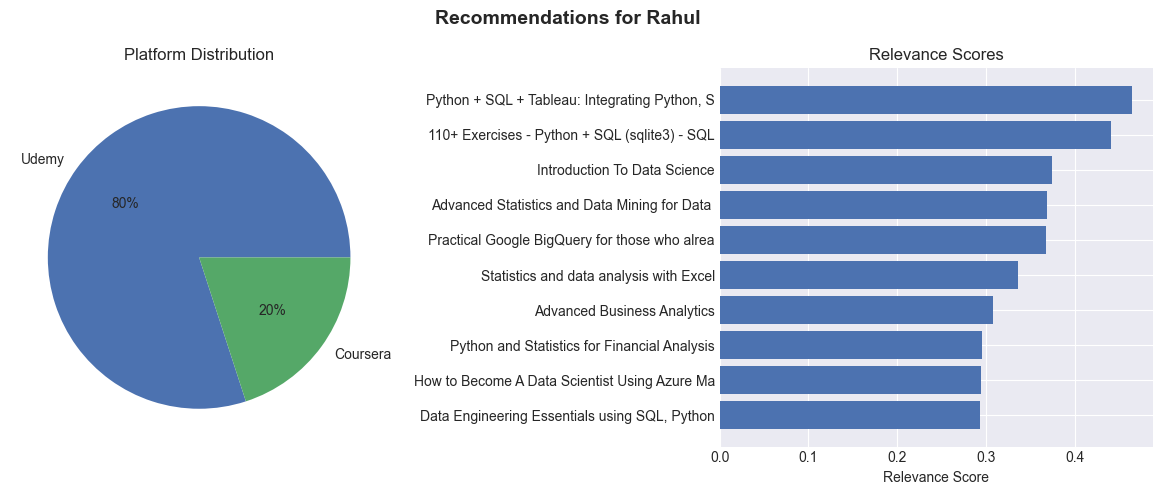

In [24]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Recommendations for {learner['name']}", fontsize=14, fontweight='bold')

axes[0].pie(recommendations['platform'].value_counts(),
            labels=recommendations['platform'].value_counts().index,
            autopct='%1.0f%%',
            colors=['#4C72B0','#55A868','#C44E52','#8172B2'])
axes[0].set_title('Platform Distribution')

axes[1].barh(recommendations['title'].str[:45].iloc[::-1],
             recommendations['score'].iloc[::-1],
             color='#4C72B0')
axes[1].set_xlabel('Relevance Score')
axes[1].set_title('Relevance Scores')

plt.tight_layout()
plt.show()